In [1]:
import os
import cv2
import json
import math
import random
import numpy as np
import pandas as pd
from scipy.spatial.transform import Rotation as R
import traceback

# ======================= User Config =======================
SYNC_CSV_PATH = "../franka_research3/fr3_matched_joint_angle.csv"
POSE1_ARUCO_JSON_PATH = "../franka_research3/pose1_aruco_pose_summary.json"
POSE2_ARUCO_JSON_PATH = "../franka_research3/pose2_aruco_pose_summary.json"
CALIB_DIR = "../franka_research3/franka_research3_calib_cam_from_conf"

# 저장 경로
OUT_DIR = "./franka_research3_to_DREAM"

# 이미지 왜곡 계수를 투영에 반영할지 여부(원본 이미지에 맞추는 용도)
USE_DISTORTION = True

# 파일명 내 시리얼 → 뷰 매핑
serial_to_view = {
    '41182735': "view1",
    '49429257': "view2",
    '44377151': "view3",
    '49045152': "view4"
}

# ======================= Kinematics =======================
def get_modified_dh_matrix(a, d, alpha, theta):
    """Craig식 Modified DH: T = Rx(alpha) @ Tx(a) @ Rz(theta) @ Tz(d)"""
    alpha_rad = math.radians(alpha)
    theta_rad = math.radians(theta)

    Rx = np.array([
        [1, 0, 0, 0],
        [0, np.cos(alpha_rad), -np.sin(alpha_rad), 0],
        [0, np.sin(alpha_rad),  np.cos(alpha_rad), 0],
        [0, 0, 0, 1]
    ])
    Tx = np.array([
        [1, 0, 0, a],
        [0, 1, 0, 0],
        [0, 0, 1, 0],
        [0, 0, 0, 1]
    ])
    Rz = np.array([
        [np.cos(theta_rad), -np.sin(theta_rad), 0, 0],
        [np.sin(theta_rad),  np.cos(theta_rad), 0, 0],
        [0, 0, 1, 0],
        [0, 0, 0, 1]
    ])
    Tz = np.array([
        [1, 0, 0, 0],
        [0, 1, 0, 0],
        [0, 0, 1, d],
        [0, 0, 0, 1]
    ])
    return Rx @ Tx @ Rz @ Tz

def angle_to_joint_coordinate(joint_angles, selected_view):
    """Converts 7 joint angles to 3D coordinates using forward kinematics."""
    # DH Parameters for Franka Research 3 (FR3) robot (meters and degrees)
    # IMPORTANT: Verify these parameters match your robot.
    fr3_dh_parameters = [
        {'a': 0,      'd': 0.333, 'alpha':   0, 'theta_offset': 0}, #1
        {'a': 0,      'd': 0,     'alpha': -90, 'theta_offset': 0}, #2
        {'a': 0,      'd': 0.316, 'alpha':  90, 'theta_offset': 0}, #3
        {'a': 0.0825,  'd': 0,     'alpha':  90, 'theta_offset': 0}, #4
        {'a': -0.0825, 'd': 0.384, 'alpha': -90, 'theta_offset': 0}, #5
        {'a': 0,      'd': 0,     'alpha':  90, 'theta_offset': 0}, #6
        {'a': 0.088,  'd': 0,     'alpha':  90, 'theta_offset': 0}, #7 
        {'a': 0,      'd': 0.107, 'alpha':   0, 'theta_offset': 0}  # flanger
    ]
    
    # Rotational correction for the robot base depending on the camera view
    view_rotations = {
        'view1': R.from_euler('zyx', [90, 180, 0], degrees=True), # Front (reference)
        'view4': R.from_euler('zyx', [90, 180, 0], degrees=True), # Top
        'view3': R.from_euler('zyx', [90, 180, 0], degrees=True), # Left
        'view2': R.from_euler('zyx', [90, 180, 0], degrees=True)  # Right
    }
    
    T_base_correction = np.eye(4)
    if selected_view in view_rotations:
        T_base_correction[:3, :3] = view_rotations[selected_view].as_matrix()

    T_cumulative = T_base_correction
    joint_coords_3d = [np.array([0, 0, 0])] # J0 (base) position
    
    base_point = np.array([[0], [0], [0], [1]])
    for i, angle_rad in enumerate(joint_angles):
        params = fr3_dh_parameters[i]
        theta_deg = math.degrees(angle_rad) + params['theta_offset']
        
        T_i = get_modified_dh_matrix(params['a'], params['d'], params['alpha'], theta_deg)
        T_cumulative = T_cumulative @ T_i
        
        joint_pos = T_cumulative @ base_point
        joint_coords_3d.append(joint_pos[:3, 0])
        
    return np.array(joint_coords_3d, dtype=np.float32)

# ======================= Projection =======================
def project_to_pixel(coords_3d, aruco_result, camera_matrix, dist_coeffs):
    """Projects 3D coordinates onto the 2D image plane."""
    Rvec = np.array([
        aruco_result['rvec_x'],
        aruco_result['rvec_y'],
        aruco_result['rvec_z']
    ], dtype=np.float32)
    Tvec = np.array([
        aruco_result['tvec_x'],
        aruco_result['tvec_y'],
        aruco_result['tvec_z']
    ], dtype=np.float32).reshape(3, 1)

    pixel_coords, _ = cv2.projectPoints(
        coords_3d, Rvec, Tvec, camera_matrix, dist_coeffs
    )
    return pixel_coords.reshape(-1, 2)


# ======================= Dataset Builder =======================
def build_sample_for_row(row, aruco_result, calib_data, view_name, cam_name):
    # 1) 7축 + 손가락 (손가락은 FK 미사용, 로그만)
    joint7 = [float(row[f'position_fr3_joint{j}']) for j in range(1, 8)]
    finger1 = float(row.get('position_fr3_finger_joint1', 0.0))
    finger2 = float(row.get('position_fr3_finger_joint2', finger1))

    # 2) FK 입력: 7 DoF + flanger(0.0 rad)
    fk_angles = joint7 + [0.0]
    joint_world = angle_to_joint_coordinate(fk_angles, view_name)  # (N,3) WORLD/BASE

    # 3) 픽셀 투영 (OpenCV: WORLD->CAM extrinsic 사용)
    K = np.array(calib_data["camera_matrix"], dtype=np.float64)
    dist = np.array(calib_data["distortion_coeffs"], dtype=np.float64)
    pixel_coords = project_to_pixel(joint_world, aruco_result, K, dist)

    # 4) 카메라 프레임 3D 좌표도 생성 (location, keypoints.location 용)
    rvec = np.array(
        [aruco_result['rvec_x'], aruco_result['rvec_y'], aruco_result['rvec_z']],
        dtype=np.float64
    ).reshape(3, 1)
    tvec = np.array(
        [aruco_result['tvec_x'], aruco_result['tvec_y'], aruco_result['tvec_z']],
        dtype=np.float64
    ).reshape(3, 1)
    R_cam_world, _ = cv2.Rodrigues(rvec)
    Xw = joint_world.astype(np.float64)                   # (N,3)
    joint_cam = (R_cam_world @ Xw.T).T + tvec.ravel()     # (N,3)

    # 5) 기준점(location) = link0(J0) in CAMERA
    base_cam = joint_cam[0].astype(float).tolist()

    # 6) keypoints (이름-좌표 매핑)
    LINK_NAMES = [
        "panda_link0", "panda_link1","panda_link2","panda_link3",
        "panda_link4","panda_link5", "panda_link6","panda_link7","panda_hand"
    ]
    n = min(len(LINK_NAMES), joint_cam.shape[0])
    keypoints = []
    for i in range(n):
        keypoints.append({
            "name": LINK_NAMES[i],
            "location": [float(joint_cam[i, 0]), float(joint_cam[i, 1]), float(joint_cam[i, 2])],
            "projected_location": [float(pixel_coords[i, 0]), float(pixel_coords[i, 1])]
        })

    # 7) joints 기록 (손가락 포함)
    JOINT_NAMES = [
        "panda_joint1","panda_joint2","panda_joint3","panda_joint4",
        "panda_joint5","panda_joint6","panda_joint7",
        "panda_finger_joint1" # "panda_finger_joint2"
    ]
    full_for_log = joint7  + [finger1] # + [finger2]
    joints_out = [
        {"name": n, "position": float(v), "velocity": 0.0}
        for n, v in zip(JOINT_NAMES, full_for_log)
    ]

    # 8) 샘플 조립 — visibility는 요청대로 1 고정
    sample = {
        "objects": [{
            "class": "panda",
            "visibility": 1,
            "location": base_cam,
            "keypoints": keypoints
        }],
        "sim_state": {"joints": joints_out},
        "meta": {
            "image_path": row["image_path"],
            "view": view_name,
            "cam": cam_name,
            "K": K.tolist(),
            "dist_coeffs": dist.tolist(),
            "aruco_rvec_tvec": {
                "rvec": [float(rvec[0,0]), float(rvec[1,0]), float(rvec[2,0])],
                "tvec": [float(tvec[0,0]), float(tvec[1,0]), float(tvec[2,0])]
            }
        }
    }
    return sample
# ======================= Main =======================
def main():
    os.makedirs(OUT_DIR, exist_ok=True)

    # 1) 데이터 로드
    try:
        df_sync = pd.read_csv(SYNC_CSV_PATH)
        with open(POSE1_ARUCO_JSON_PATH, 'r') as f:
            pose1_aruco_results = json.load(f)
        with open(POSE2_ARUCO_JSON_PATH, 'r') as f:
            pose2_aruco_results = json.load(f)
    except FileNotFoundError as e:
        print(f"❌ File not found: {e}")
        return

    # 3) 전체 행을 순회하며 샘플 생성
    total = 0
    saved = 0
    skipped = 0

    for idx, row in df_sync.iterrows():
        total += 1
        try:
            image_path = row['image_path']
            img_name = os.path.basename(image_path)
            parts = img_name.split('_')
            serial_str = parts[1]  # e.g., '41182735'
            cam_str = parts[2]     # 'left' or 'right'
            view_str = serial_to_view.get(serial_str, None)

            if view_str is None:
                print(f"⚠️  [{idx}] Unknown serial '{serial_str}' → view mapping failed. Skipping.")
                skipped += 1
                continue

            # pose별 ArUco/Calib 선택
            if 'pose1' in image_path:
                current_aruco_data = pose1_aruco_results
                pose_name = "pose1"
            elif 'pose2' in image_path:
                current_aruco_data = pose2_aruco_results
                pose_name = "pose2"
            else:
                print(f"⚠️  [{idx}] Pose info missing in path: {image_path}. Skipping.")
                skipped += 1
                continue

            # 해당 view+cam의 ArUco 결과 찾기
            try:
                aruco_result = next(item for item in current_aruco_data
                                    if item['view'] == view_str and item['cam'] == (cam_str + 'cam'))
            except StopIteration:
                print(f"⚠️  [{idx}] ArUco Not Found for {pose_name}/{view_str}/{cam_str}. Skipping.")
                skipped += 1
                continue

            # calib 파일 로드
            calib_path = os.path.join(CALIB_DIR, f"{view_str}_{serial_str}_{cam_str + 'cam'}_calib.json")
            if not os.path.exists(calib_path):
                print(f"⚠️  [{idx}] Calib file not found: {calib_path}. Skipping.")
                skipped += 1
                continue
            with open(calib_path, 'r') as f:
                calib_data = json.load(f)

            # 샘플 생성
            sample = build_sample_for_row(
                row=row,
                aruco_result=aruco_result,
                calib_data=calib_data,
                view_name=view_str,
                cam_name=cam_str
            )

            # 개별 JSON 저장
            img_stem = os.path.splitext(img_name)[0]
            out_json = os.path.join(OUT_DIR, f"{img_stem}.json")
            with open(out_json, "w", encoding="utf-8") as f:
                json.dump(sample, f, ensure_ascii=False, indent=2)

            saved += 1
            if saved % 100 == 0:
                print(f"✅ Saved {saved} / {total} (progress)")

        except Exception as e:
            print(f"\n❌ [{idx}] Unexpected error for {row.get('image_path', 'unknown')}: {type(e).__name__}: {e}")
            traceback.print_exc()
            skipped += 1
            continue

    print(f"\n=== Done ===\nTotal rows: {total}\nSaved: {saved}\nSkipped: {skipped}\nOutput dir: {OUT_DIR}")

if __name__ == "__main__":
    main()


✅ Saved 100 / 100 (progress)
✅ Saved 200 / 200 (progress)
✅ Saved 300 / 300 (progress)
✅ Saved 400 / 400 (progress)
✅ Saved 500 / 500 (progress)
✅ Saved 600 / 600 (progress)
✅ Saved 700 / 700 (progress)
✅ Saved 800 / 800 (progress)
✅ Saved 900 / 900 (progress)
✅ Saved 1000 / 1000 (progress)
✅ Saved 1100 / 1100 (progress)
✅ Saved 1200 / 1200 (progress)
✅ Saved 1300 / 1300 (progress)
✅ Saved 1400 / 1400 (progress)
✅ Saved 1500 / 1500 (progress)
✅ Saved 1600 / 1600 (progress)
✅ Saved 1700 / 1700 (progress)
✅ Saved 1800 / 1800 (progress)
✅ Saved 1900 / 1900 (progress)
✅ Saved 2000 / 2000 (progress)
✅ Saved 2100 / 2100 (progress)
✅ Saved 2200 / 2200 (progress)
✅ Saved 2300 / 2300 (progress)
✅ Saved 2400 / 2400 (progress)
✅ Saved 2500 / 2500 (progress)
✅ Saved 2600 / 2600 (progress)
✅ Saved 2700 / 2700 (progress)
✅ Saved 2800 / 2800 (progress)
✅ Saved 2900 / 2900 (progress)
✅ Saved 3000 / 3000 (progress)
✅ Saved 3100 / 3100 (progress)
✅ Saved 3200 / 3200 (progress)
✅ Saved 3300 / 3300 (progr

../../dataset/franka_research3/franka_research3_pose1/Panda_dataset_1th/view1/zed_41182735_left_1756275930.683.jpg
[Reprojection] mean L2 error: 0.000px
   panda_link0: 0.000px
   panda_link1: 0.000px
   panda_link2: 0.000px
   panda_link3: 0.000px
   panda_link4: 0.000px
   panda_link5: 0.000px
   panda_link6: 0.000px
   panda_link7: 0.000px
    panda_hand: 0.000px


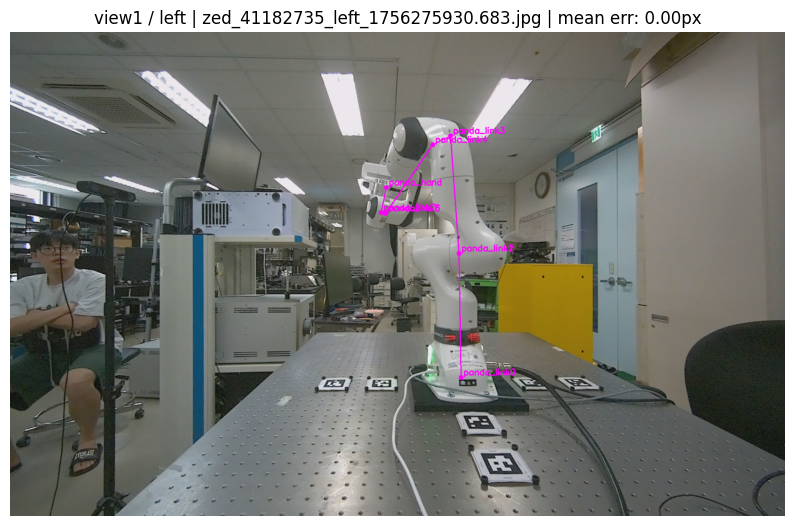

In [8]:
import os
import json
import cv2
import numpy as np
import matplotlib.pyplot as plt

def load_sample(json_path):
    with open(json_path, "r", encoding="utf-8") as f:
        sample = json.load(f)
    obj = sample["objects"][0]
    meta = sample["meta"]
    return obj, meta

def project_camframe_points(pts_cam, K, dist):
    """카메라 프레임 3D -> 픽셀 (extrinsic = I)"""
    rvec = np.zeros((3,1), np.float64)
    tvec = np.zeros((3,1), np.float64)
    pts = np.asarray(pts_cam, dtype=np.float64).reshape(-1,1,3)
    K = np.asarray(K, dtype=np.float64)
    dist = np.asarray(dist, dtype=np.float64)
    img_pts, _ = cv2.projectPoints(pts, rvec, tvec, K, dist)
    return img_pts.reshape(-1,2)

def visualize_json(json_path, show_ids=True, compute_reproj_error=True, point_radius=6, thickness=2):
    obj, meta = load_sample(json_path)
    image_path = os.path.join("../", meta["image_path"])
    print(image_path)
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"Image not found: {image_path}")

    # 이미지 로드 (왜곡 보정하지 않음: projected_location이 왜곡 좌표라고 가정)
    img_bgr = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # 키포인트(픽셀) 수집
    names = []
    uv_from_json = []
    cam3d = []
    for kp in obj["keypoints"]:
        names.append(kp["name"])
        uv_from_json.append(kp["projected_location"])
        cam3d.append(kp["location"])
    uv_from_json = np.asarray(uv_from_json, dtype=np.float64)
    cam3d = np.asarray(cam3d, dtype=np.float64)

    # 재투영 (옵션)
    reproj_errs = None
    if compute_reproj_error and cam3d.size > 0:
        K = meta["K"]
        dist = meta["dist_coeffs"]
        uv_reproj = project_camframe_points(cam3d, K, dist)
        reproj_errs = np.linalg.norm(uv_reproj - uv_from_json, axis=1)
        mean_err = float(reproj_errs.mean())
        print(f"[Reprojection] mean L2 error: {mean_err:.3f}px")
        for n, e in zip(names, reproj_errs):
            print(f"  {n:>12s}: {e:.3f}px")

    # 드로잉
    overlay = img_rgb.copy()
    color = (255, 0, 255)  # magenta
    for i, (u, v) in enumerate(uv_from_json.astype(int)):
        cv2.circle(overlay, (u, v), point_radius, color, -1)
        if show_ids:
            label = f"{names[i]}"
            cv2.putText(overlay, label, (u + 6, v - 6), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, thickness)

        if i > 0:
            u_prev, v_prev = uv_from_json[i-1].astype(int)
            cv2.line(overlay, (u_prev, v_prev), (u, v), color, thickness)

    title = f"{meta.get('view','?')} / {meta.get('cam','?')} | {os.path.basename(image_path)}"
    if reproj_errs is not None:
        title += f" | mean err: {reproj_errs.mean():.2f}px"

    plt.figure(figsize=(10, 8))
    plt.imshow(overlay)
    plt.axis("off")
    plt.title(title)
    plt.show()

if __name__ == "__main__":
    # 예시: 하나의 JSON 파일 경로를 넣어 실행
    json_path = "/home/najo/NAS/DIP/2025_ICRA_Multi_View_Robot_Pose_Estimation/dataset/Converted_dataset/franka_research3_to_DREAM/zed_41182735_left_1756275930.683.json"  # <- 여기를 교체
    visualize_json(json_path)
